# Library imports

In [39]:
import os
import glob
import numpy as np
import soundfile as sf
import polars as pl
import librosa
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from IPython.display import Audio, display
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['figure.dpi'] = 100

# Preprocessing

Lectura de archivos de audio

Convención de etiquetas:
- PD → label = 1 (clase positiva: enfermedad presente)
- HD → label = 0 (clase negativa: sano)

In [2]:
BASE_PATH = "data"

files_pd = sorted(glob.glob(os.path.join(BASE_PATH, "PD", "*.wav")))
files_hd = sorted(glob.glob(os.path.join(BASE_PATH, "HC", "*.wav")))

df_metadata = pl.DataFrame({
    "filepath": files_pd + files_hd,
    "filename": [os.path.basename(f) for f in files_pd + files_hd],
    "label": [1] * len(files_pd) + [0] * len(files_hd),
    "label_name": ["PD"] * len(files_pd) + ["HD"] * len(files_hd)
})

print(f"Parkinson files: {len(files_pd)}")
print(f"Healthy files: {len(files_hd)}")

Parkinson files: 50
Healthy files: 50


## Carga de Señales de Audio (Formas de Onda Crudas)

### Señal digital de audio

Un archivo de audio digital contiene una secuencia de valores de amplitud muestreados a una frecuencia fija (*sample rate*, $sr$):

$$x[n] = x\left(\frac{n}{sr}\right), \quad n = 0, 1, \ldots, N-1$$

donde $N$ es el total de muestras y la duración es $T = N / sr$.

### Decisión de diseño: $sr = 16{,}000$ Hz

Remuestreamos todos los audios a 16 kHz porque:

1. **Teorema de Nyquist-Shannon**: La voz humana relevante está bajo 8 kHz, por lo que $sr \geq 2 \times 8000 = 16000$ es suficiente.
2. **Eficiencia**: Menos muestras que 44.1 kHz sin perder información vocal relevante.


## Preprocesamiento Mínimo

Cuando trabajamos con formas de onda crudas como entrada a modelos de deep learning, el objetivo es **preservar la mayor cantidad de información posible** y dejar que el modelo aprenda sus propias representaciones (Ravanelli & Bengio, 2018).

Por eso, el preprocesamiento se limita a dos operaciones:

### 1. Recorte de silencios (*trimming*)

Elimina segmentos al inicio y final donde la energía está por debajo de un umbral. Se calcula la energía en dB por ventanas:

$$E_{dB}[m] = 20 \times \log_{10}(\text{RMS}[m])$$

donde $\text{RMS}[m] = \sqrt{\frac{1}{K} \sum_{k} x[k]^2}$ es la energía de la ventana $m$.

Se recortan las ventanas donde $E_{dB}[m] < E_{dB}^{max} - \text{top\_db}$. Usamos $\text{top\_db} = 20$, valor estándar en la literatura.

**¿Por qué?** Los silencios iniciales/finales no contienen información sobre la condición del paciente y añaden variabilidad no informativa.

### 2. Normalización de amplitud (*peak normalization*)

Escala la señal para que su valor absoluto máximo sea un valor objetivo:

$$\hat{x}[n] = 0.95 \times \frac{x[n]}{\max(|x[n]|)}$$

**¿Por qué?** Diferentes micrófonos y distancias de grabación producen volúmenes distintos. Sin normalización, el modelo podría aprender a clasificar por volumen en lugar de por patrones vocales.

### Orden del pipeline

1. **Primero** recortar silencios → eliminamos muestras no informativas.
2. **Después** normalizar → la normalización se calcula solo sobre la voz activa.

In [13]:
TARGET_SR = 16000

waveforms = []
durations = []

for i, filepath in enumerate(df_metadata["filepath"].to_list()):
    wf, sr_orig = sf.read(filepath)

    # Convertir a mono si es estéreo
    if wf.ndim > 1:
        wf = wf.mean(axis=1)

    # Remuestrear a 16 kHz si es necesario
    if sr_orig != TARGET_SR:
        wf = librosa.resample(wf, orig_sr=sr_orig, target_sr=TARGET_SR)
        wf = librosa.resample(wf, orig_sr=sr_orig, target_sr=TARGET_SR)

    waveforms.append(wf)
    durations.append(len(wf) / TARGET_SR)

df_metadata = df_metadata.with_columns(
    pl.Series("duration_s", durations)
)

print(f"✅ {len(waveforms)} archivos cargados a {TARGET_SR} Hz")
print(f"\nEstadísticas de duración (segundos):")
print(df_metadata.group_by("label_name").agg([
    pl.col("duration_s").mean().alias("media"),
    pl.col("duration_s").min().alias("min"),
    pl.col("duration_s").max().alias("max")
]))

✅ 100 archivos cargados a 16000 Hz

Estadísticas de duración (segundos):
shape: (2, 4)
┌────────────┬──────────┬───────────┬───────────┐
│ label_name ┆ media    ┆ min       ┆ max       │
│ ---        ┆ ---      ┆ ---       ┆ ---       │
│ str        ┆ f64      ┆ f64       ┆ f64       │
╞════════════╪══════════╪═══════════╪═══════════╡
│ PD         ┆ 4.689691 ┆ 1.3895625 ┆ 10.523    │
│ HD         ┆ 4.078074 ┆ 1.6823125 ┆ 8.4749375 │
└────────────┴──────────┴───────────┴───────────┘


In [32]:
def preprocess_waveform(waveform, target_peak=0.95, top_db=20, eps=1e-8):
    """
    Pipeline de preprocesamiento mínimo (orden corregido).
    Paso 1: Normalización de amplitud.
    Paso 2: Recorte de silencios iniciales/finales.
    """
    # Paso 1: Normalización peak
    peak = np.max(np.abs(waveform))
    if peak > eps:
        wf_normalized = target_peak * (waveform / peak)
    else:
        wf_normalized = waveform

    # Paso 2: Recorte de silencios
    wf_trimmed, _ = librosa.effects.trim(wf_normalized, top_db=top_db)

    return wf_trimmed

# Reaplicar a todos los audios
waveforms_processed = []
durations_processed = []

for wf in waveforms:
    wf_proc = preprocess_waveform(wf)
    waveforms_processed.append(wf_proc)
    durations_processed.append(len(wf_proc) / TARGET_SR)

df_metadata = df_metadata.with_columns(
    pl.Series("duration_s_processed", durations_processed)
)

print("✅ Preprocesamiento completado (orden corregido)")
print(f"\nComparación de duraciones (segundos):")
print(df_metadata.group_by("label_name").agg([
    pl.col("duration_s").mean().alias("original_media"),
    pl.col("duration_s_processed").mean().alias("procesada_media"),
]))

✅ Preprocesamiento completado (orden corregido)

Comparación de duraciones (segundos):
shape: (2, 3)
┌────────────┬────────────────┬─────────────────┐
│ label_name ┆ original_media ┆ procesada_media │
│ ---        ┆ ---            ┆ ---             │
│ str        ┆ f64            ┆ f64             │
╞════════════╪════════════════╪═════════════════╡
│ HD         ┆ 4.078074       ┆ 4.026524        │
│ PD         ┆ 4.689691       ┆ 4.600234        │
└────────────┴────────────────┴─────────────────┘


## Visualización de recorte de sonido

🔵 Persona Sana (HD):


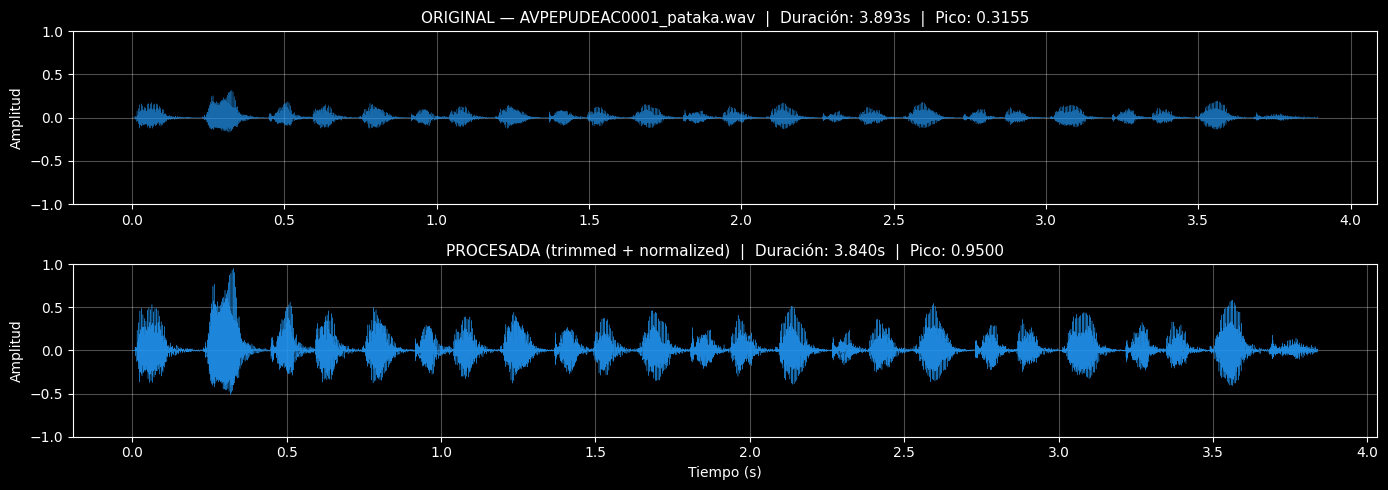


🔴 Paciente con Parkinson (PD):


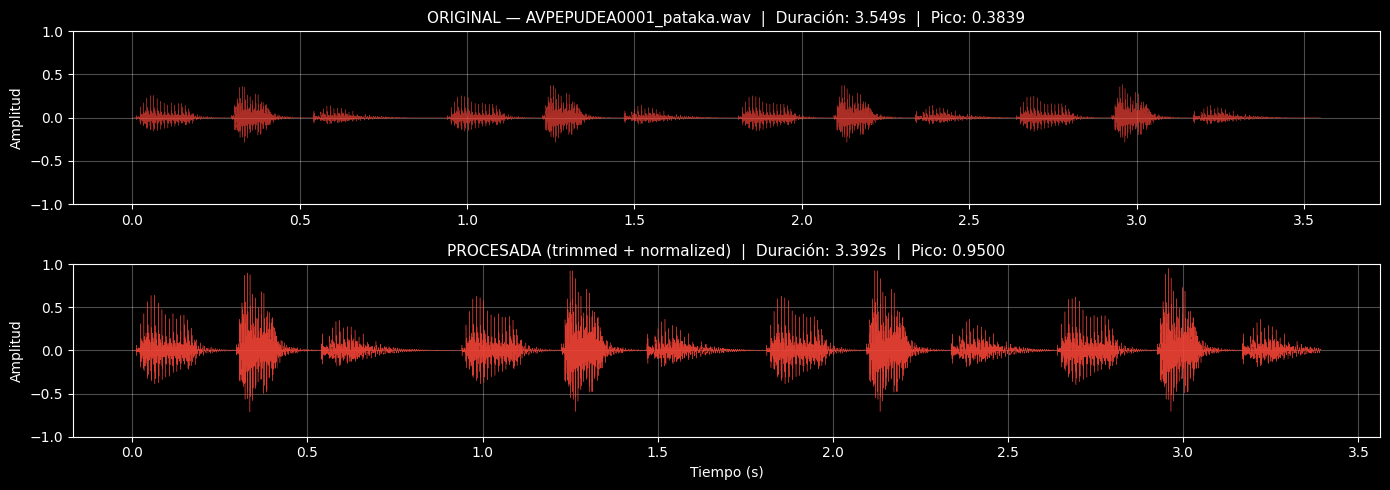

In [33]:
def plot_before_after(idx, label_name):
    """Visualiza una señal antes y después del preprocesamiento."""
    wf_orig = waveforms[idx]
    wf_proc = waveforms_processed[idx]
    t_orig = np.arange(len(wf_orig)) / TARGET_SR
    t_proc = np.arange(len(wf_proc)) / TARGET_SR

    fig, axes = plt.subplots(2, 1, figsize=(14, 5))

    color = "#2196F3" if label_name == "HD" else "#F44336"

    # Original
    axes[0].plot(t_orig, wf_orig, color=color, linewidth=0.3, alpha=0.7)
    axes[0].set_title(f"ORIGINAL — {df_metadata['filename'][idx]}  |  "
                      f"Duración: {len(wf_orig)/TARGET_SR:.3f}s  |  "
                      f"Pico: {np.max(np.abs(wf_orig)):.4f}", fontsize=11)
    axes[0].set_ylabel("Amplitud")
    axes[0].set_ylim([-1, 1])
    axes[0].grid(True, alpha=0.3)

    # Procesada
    axes[1].plot(t_proc, wf_proc, color=color, linewidth=0.3, alpha=0.9)
    axes[1].set_title(f"PROCESADA (trimmed + normalized)  |  "
                      f"Duración: {len(wf_proc)/TARGET_SR:.3f}s  |  "
                      f"Pico: {np.max(np.abs(wf_proc)):.4f}", fontsize=11)
    axes[1].set_ylabel("Amplitud")
    axes[1].set_xlabel("Tiempo (s)")
    axes[1].set_ylim([-1, 1])
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Un ejemplo de cada clase
idx_hd = df_metadata.filter(pl.col("label_name") == "HD").row_nr(0) if hasattr(df_metadata, 'row_nr') else \
         df_metadata["label_name"].to_list().index("HD")
idx_pd = df_metadata["label_name"].to_list().index("PD")

print("🔵 Persona Sana (HD):")
plot_before_after(idx_hd, "HD")

print("\n🔴 Paciente con Parkinson (PD):")
plot_before_after(idx_pd, "PD")

## Unificación de Longitudes (Padding / Truncating)

### ¿Por qué es necesario?

PyTorch trabaja con **tensores de tamaño fijo** dentro de cada batch. Si una señal tiene 20,000 muestras y otra 50,000, no pueden agruparse en un mismo tensor. Necesitamos que todas tengan la misma longitud $L$.

### Estrategia

Dada una longitud objetivo $L$:

- **Si la señal es más corta** ($N < L$): Se rellena con ceros al final (*zero-padding*). Matemáticamente:

$$x_{pad}[n] = \begin{cases} x[n] & \text{si } n < N \\ 0 & \text{si } N \leq n < L \end{cases}$$

- **Si la señal es más larga** ($N > L$): Se recorta desde el inicio (*truncating*), conservando los primeros $L$ valores:

$$x_{trunc}[n] = x[n], \quad n = 0, 1, \ldots, L-1$$

### ¿Cómo elegir $L$?

Opciones comunes:
- **Duración máxima**: No se pierde información, pero genera mucho padding en señales cortas.
- **Percentil 95**: Buen balance — se preserva la mayoría de señales completas y se limita el padding excesivo.
- **Duración media**: Compromiso agresivo — muchas señales se recortan.

Analizaremos la distribución de duraciones para tomar una decisión informada.

Distribución de duraciones procesadas (segundos):
  Percentil 50 (mediana): 4.025s  →  64,400 muestras
  Percentil 75:           5.456s  →  87,296 muestras
  Percentil 90:           6.640s  →  106,240 muestras
  Percentil 95:           7.470s  →  119,525 muestras
  Máximo:                 10.464s  →  167,424 muestras


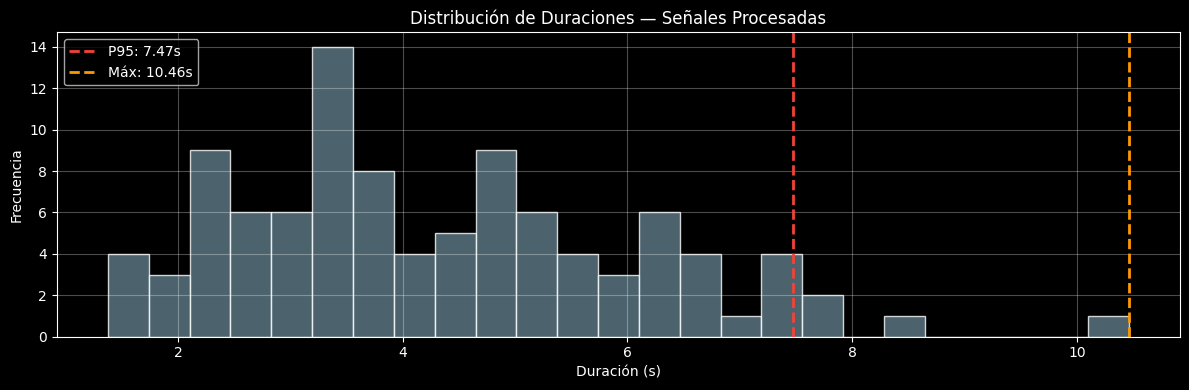

In [34]:
# Analizar distribución de duraciones procesadas
durations_arr = np.array(durations_processed)

p50 = np.percentile(durations_arr, 50)
p75 = np.percentile(durations_arr, 75)
p90 = np.percentile(durations_arr, 90)
p95 = np.percentile(durations_arr, 95)
d_max = np.max(durations_arr)

print("Distribución de duraciones procesadas (segundos):")
print(f"  Percentil 50 (mediana): {p50:.3f}s  →  {int(p50 * TARGET_SR):,} muestras")
print(f"  Percentil 75:           {p75:.3f}s  →  {int(p75 * TARGET_SR):,} muestras")
print(f"  Percentil 90:           {p90:.3f}s  →  {int(p90 * TARGET_SR):,} muestras")
print(f"  Percentil 95:           {p95:.3f}s  →  {int(p95 * TARGET_SR):,} muestras")
print(f"  Máximo:                 {d_max:.3f}s  →  {int(d_max * TARGET_SR):,} muestras")

# Visualizar
plt.figure(figsize=(12, 4))
plt.hist(durations_arr, bins=25, color="#607D8B", edgecolor="white", alpha=0.8)
plt.axvline(p95, color="#F44336", linestyle="--", linewidth=2, label=f"P95: {p95:.2f}s")
plt.axvline(d_max, color="#FF9800", linestyle="--", linewidth=2, label=f"Máx: {d_max:.2f}s")
plt.xlabel("Duración (s)")
plt.ylabel("Frecuencia")
plt.title("Distribución de Duraciones — Señales Procesadas")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Aplicación de Padding / Truncating

Se unifica la longitud de todas las señales a **$L = 120{,}000$ muestras (7.5 segundos)**, correspondiente al percentil 95 de las duraciones.

- El 95% de las señales se preservan completas (solo se les agrega ceros al final).
- El 5% restante se recorta, perdiendo información mínima al final de la grabación.
- El *zero-padding* no introduce artefactos en la señal, simplemente extiende con silencio.

In [37]:
TARGET_LENGTH = 120000  # 7.5 segundos a 16 kHz

def pad_or_truncate(waveform, target_length):

    """
    Ajusta la señal a una longitud fija.
    - Señales cortas: zero-padding al final.
    - Señales largas: truncado desde el inicio.
    """
    n = len(waveform)
    if n < target_length:
        # Padding con ceros
        padded = np.zeros(target_length)
        padded[:n] = waveform
        return padded
    else:
        # Truncar
        return waveform[:target_length]

# Aplicar a todas las señales
waveforms_fixed = [pad_or_truncate(wf, TARGET_LENGTH) for wf in waveforms_processed]

# Verificar
n_padded = sum(1 for wf in waveforms_processed if len(wf) < TARGET_LENGTH)
n_truncated = sum(1 for wf in waveforms_processed if len(wf) > TARGET_LENGTH)
n_exact = sum(1 for wf in waveforms_processed if len(wf) == TARGET_LENGTH)

print(f"✅ Todas las señales unificadas a {TARGET_LENGTH:,} muestras ({TARGET_LENGTH/TARGET_SR}s)")
print(f"\n  Señales con padding (eran más cortas):  {n_padded}")
print(f"  Señales truncadas (eran más largas):     {n_truncated}")
print(f"  Señales sin cambio (longitud exacta):    {n_exact}")
print(f"\n  Shape final de cada señal: {waveforms_fixed[0].shape}")

✅ Todas las señales unificadas a 120,000 muestras (7.5s)

  Señales con padding (eran más cortas):  95
  Señales truncadas (eran más largas):     5
  Señales sin cambio (longitud exacta):    0

  Shape final de cada señal: (120000,)


## División del Dataset (Train / Validation / Test)

### ¿Por qué dividir antes de entrenar?

Es fundamental separar los datos **antes** de cualquier paso de modelado para evitar *data leakage* (fuga de información). Si el modelo ve datos de test durante el entrenamiento, las métricas de evaluación no reflejarán su capacidad de generalización real.

### Estrategia

- **Train (70%)**: Para entrenar los modelos.
- **Validation (15%)**: Para ajustar hiperparámetros y monitorear sobreajuste durante el entrenamiento.
- **Test (15%)**: Evaluación final. Solo se usa una vez.

### Estratificación

Usamos **estratificación por clase** para garantizar que la proporción HD/PD se mantenga en cada partición. Con un dataset de 100 archivos (50+50), esto es especialmente importante para evitar desbalances accidentales en particiones pequeñas.

### Reproducibilidad

Se fija una semilla aleatoria (`random_state=42`) para que la división sea exactamente replicable.

In [40]:
RANDOM_STATE = 42

# Extraer etiquetas
labels = df_metadata["label"].to_numpy()

# Índices de cada muestra
indices = np.arange(len(waveforms_fixed))

# Paso 1: Separar Test (15%)
idx_train_val, idx_test, y_train_val, y_test = train_test_split(
    indices, labels,
    test_size=0.15,
    stratify=labels,
    random_state=RANDOM_STATE
)

# Paso 2: Separar Train (70%) y Validation (15%) del restante (85%)
idx_train, idx_val, y_train, y_val = train_test_split(
    idx_train_val, y_train_val,
    test_size=0.176,  # 0.176 de 85% ≈ 15% del total
    stratify=y_train_val,
    random_state=RANDOM_STATE
)

# Reporte
print("✅ División del dataset completada")
print(f"\n{'Partición':<12} {'Total':>6} {'HD (0)':>8} {'PD (1)':>8}")
print("-" * 36)
for name, y in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    n_hd = np.sum(y == 0)
    n_pd = np.sum(y == 1)
    print(f"{name:<12} {len(y):>6} {n_hd:>8} {n_pd:>8}")
print("-" * 36)
print(f"{'Total':<12} {len(labels):>6} {np.sum(labels==0):>8} {np.sum(labels==1):>8}")

✅ División del dataset completada

Partición     Total   HD (0)   PD (1)
------------------------------------
Train            70       35       35
Validation       15        7        8
Test             15        8        7
------------------------------------
Total           100       50       50


## Dataset y DataLoader de PyTorch

### ¿Qué es un Dataset?

En PyTorch, un `Dataset` es una clase que encapsula los datos y permite acceder a cada muestra individualmente mediante un índice. Debe implementar dos métodos:

- `__len__()`: Retorna el número total de muestras.
- `__getitem__(idx)`: Retorna la muestra y su etiqueta en el índice `idx`.

### ¿Qué es un DataLoader?

El `DataLoader` envuelve al `Dataset` y se encarga de:

- **Crear batches**: Agrupa $B$ muestras en un tensor de forma $(B, 1, L)$.
- **Mezclar los datos** (*shuffle*): Aleatoriza el orden en cada época de entrenamiento.
- **Paralelizar la carga**: Usa múltiples workers para cargar datos en segundo plano.

### ¿Por qué forma $(B, 1, L)$?

Las CNNs 1D en PyTorch esperan tensores con la dimensión de canales explícita:

$$\text{input shape} = (B, C, L)$$

donde $B$ = batch size, $C$ = canales (1 para audio mono), $L$ = longitud de la señal.

In [41]:
import torch
from torch.utils.data import Dataset, DataLoader

class ParkinsonWaveformDataset(Dataset):
    """
    Dataset de formas de onda para detección de Parkinson.
    Cada muestra es un tensor de forma (1, L) con su etiqueta binaria.
    """
    def __init__(self, waveforms, labels, indices):
        self.waveforms = [waveforms[i] for i in indices]
        self.labels = [labels[i] for i in indices]

    def __len__(self):
        return len(self.waveforms)

    def __getitem__(self, idx):
        # Forma de onda: (L,) → (1, L) para el canal de audio
        x = torch.tensor(self.waveforms[idx], dtype=torch.float32).unsqueeze(0)
        y = torch.tensor(self.labels[idx], dtype=torch.float32)
        return x, y

# Crear los datasets
train_dataset = ParkinsonWaveformDataset(waveforms_fixed, labels, idx_train)
val_dataset   = ParkinsonWaveformDataset(waveforms_fixed, labels, idx_val)
test_dataset  = ParkinsonWaveformDataset(waveforms_fixed, labels, idx_test)

# Crear los DataLoaders
BATCH_SIZE = 8

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

# Verificar
x_batch, y_batch = next(iter(train_loader))
print(f"✅ DataLoaders creados correctamente")
print(f"\n  Train:      {len(train_dataset)} muestras  →  {len(train_loader)} batches")
print(f"  Validation: {len(val_dataset)} muestras  →  {len(val_loader)} batches")
print(f"  Test:       {len(test_dataset)} muestras  →  {len(test_loader)} batches")
print(f"\n  Shape de un batch (x): {x_batch.shape}  →  (batch, canales, longitud)")
print(f"  Shape de un batch (y): {y_batch.shape}  →  (batch,)")
print(f"  Etiquetas del batch:   {y_batch.tolist()}")

✅ DataLoaders creados correctamente

  Train:      70 muestras  →  9 batches
  Validation: 15 muestras  →  2 batches
  Test:       15 muestras  →  2 batches

  Shape de un batch (x): torch.Size([8, 1, 120000])  →  (batch, canales, longitud)
  Shape de un batch (y): torch.Size([8])  →  (batch,)
  Etiquetas del batch:   [1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0]


# Arquitecturas

## Arquitectura 1: Red Neuronal Convolucional 1D (CNN 1D)

### ¿Por qué CNN 1D para audio crudo?

Una CNN 1D aplica filtros que se deslizan a lo largo del eje temporal de la señal. Cada filtro aprende a detectar un patrón local específico (un "motivo" temporal). Esto es análogo a cómo una CNN 2D detecta bordes o texturas en imágenes, pero en una sola dimensión.

### ¿Qué puede aprender de señales de Parkinson?

- **Capas iniciales**: Patrones de baja abstracción como oscilaciones de frecuencia fundamental, variaciones rápidas de amplitud (shimmer/jitter).
- **Capas profundas**: Combinaciones de patrones que representan irregularidades articulatorias, temblor vocal, o cambios de ritmo característicos de la enfermedad.

### Operación de convolución 1D

Dado un filtro $w$ de tamaño $k$ y una señal de entrada $x$, la salida en la posición $t$ es:

$$(x * w)[t] = \sum_{i=0}^{k-1} x[t + i] \cdot w[i]$$

Cada capa convolucional aplica múltiples filtros, generando múltiples "mapas de características" que capturan diferentes patrones temporales.

### Arquitectura propuesta

| Capa | Operación | Salida |
|------|-----------|--------|
| Conv1d + ReLU + BatchNorm | 1 → 32 filtros, kernel=7 | Patrones locales finos |
| MaxPool1d(4) | Reducción temporal ×4 | Compresión |
| Conv1d + ReLU + BatchNorm | 32 → 64 filtros, kernel=5 | Patrones de nivel medio |
| MaxPool1d(4) | Reducción temporal ×4 | Compresión |
| Conv1d + ReLU + BatchNorm | 64 → 128 filtros, kernel=3 | Patrones abstractos |
| AdaptiveAvgPool1d(1) | Promedio global | Vector fijo |
| Linear + Dropout | 128 → 1 | Clasificación binaria |

In [42]:
import torch.nn as nn

class CNN1D(nn.Module):
    """
    CNN 1D para clasificación binaria de formas de onda crudas.
    Entrada: (batch, 1, 120000)
    Salida:  (batch, 1) → probabilidad de Parkinson
    """
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            # Bloque 1: Captura patrones locales finos
            nn.Conv1d(in_channels=1, out_channels=32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4),

            # Bloque 2: Patrones de nivel medio
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4),

            # Bloque 3: Patrones abstractos
            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            # Promedio global: reduce cualquier longitud temporal a 1 valor por filtro
            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        # x: (batch, 1, 120000)
        x = self.features(x)     # (batch, 128, 1)
        x = x.squeeze(-1)        # (batch, 128)
        x = self.classifier(x)   # (batch, 1)
        return x.squeeze(-1)     # (batch,)

# Verificar la arquitectura
model_cnn = CNN1D()
x_test = torch.randn(2, 1, TARGET_LENGTH)  # batch de 2 señales ficticias
y_test = model_cnn(x_test)

print("✅ CNN 1D creada correctamente")
print(f"\n  Entrada:  {x_test.shape}  →  (batch, canales, longitud)")
print(f"  Salida:   {y_test.shape}  →  (batch,)")
print(f"\n  Parámetros totales: {sum(p.numel() for p in model_cnn.parameters()):,}")

✅ CNN 1D creada correctamente

  Entrada:  torch.Size([2, 1, 120000])  →  (batch, canales, longitud)
  Salida:   torch.Size([2])  →  (batch,)

  Parámetros totales: 35,841


## CNN 1D — Versión Simplificada

El modelo anterior no generalizó porque con solo 70 muestras de entrenamiento, una red con demasiados parámetros memoriza el training sin aprender patrones transferibles al validation.

### Cambios respecto a la versión anterior

| Aspecto | Anterior | Simplificada |
|---------|----------|-------------|
| Filtros | 32 → 64 → 128 | 16 → 32 → 64 |
| Pooling | MaxPool(4) | MaxPool(8) — más agresivo |
| Dropout | 0.3 | 0.5 — más regularización |
| Learning rate | 1e-3 | 5e-4 — más conservador |

El pooling más agresivo reduce rápidamente la dimensión temporal, forzando al modelo a capturar patrones globales en lugar de memorizar detalles locales.

In [45]:
class CNN1D_Light(nn.Module):
    """
    CNN 1D simplificada para datasets pequeños.
    Menos parámetros + más regularización = mejor generalización.
    """
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, padding=3),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(8),

            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(8),

            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.squeeze(-1)
        x = self.classifier(x)
        return x.squeeze(-1)

# Verificar
model_cnn_light = CNN1D_Light()
params_original = sum(p.numel() for p in CNN1D().parameters())
params_light = sum(p.numel() for p in model_cnn_light.parameters())

print(f"✅ CNN 1D Light creada")
print(f"\n  Parámetros modelo original:     {params_original:,}")
print(f"  Parámetros modelo simplificado: {params_light:,}")
print(f"  Reducción: {100*(1 - params_light/params_original):.1f}%")

✅ CNN 1D Light creada

  Parámetros modelo original:     35,841
  Parámetros modelo simplificado: 9,217
  Reducción: 74.3%


# Entrenamientos

## Entrenamientos y evaluación

In [47]:
def train_and_evaluate(model, train_loader, val_loader, device,
                       epochs=50, lr=1e-3, patience=7):
    """
    Entrena y evalúa cualquier modelo binario.
    Retorna el modelo con mejores pesos y su historial completo.
    """
    model = model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_loss = float("inf")
    patience_counter = 0
    best_state = None

    print(f"{'Época':>6} {'Train Loss':>12} {'Val Loss':>12} {'Train Acc':>12} {'Val Acc':>12}")
    print("-" * 58)

    for epoch in range(1, epochs + 1):
        # Train
        model.train()
        t_loss, t_correct, t_total = 0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            t_loss += loss.item() * len(y)
            t_correct += ((torch.sigmoid(out) >= 0.5).float() == y).sum().item()
            t_total += len(y)

        # Validation
        model.eval()
        v_loss, v_correct, v_total = 0, 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                v_loss += loss.item() * len(y)
                v_correct += ((torch.sigmoid(out) >= 0.5).float() == y).sum().item()
                v_total += len(y)

        train_loss = t_loss / t_total
        val_loss = v_loss / v_total
        train_acc = t_correct / t_total
        val_acc = v_correct / v_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"{epoch:>6} {train_loss:>12.4f} {val_loss:>12.4f} {train_acc:>12.3f} {val_acc:>12.3f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\n⏹ Early stopping en época {epoch}")
                break

    model.load_state_dict(best_state)

    return model, history, best_val_loss

## Registro y ejecución de modelos

In [48]:
# ============================================================
# REGISTRO DE MODELOS
# ============================================================
# Agregar nuevas arquitecturas aquí con su configuración
MODELS = {
    "CNN1D": {
        "class": CNN1D,
        "lr": 1e-3,
        "patience": 7
    },
    "CNN1D_Light": {
        "class": CNN1D_Light,
        "lr": 5e-4,
        "patience": 10
    }
}

# ============================================================
# ENTRENAMIENTO DE TODOS LOS MODELOS
# ============================================================
results = {}

for name, config in MODELS.items():
    print(f"\n{'='*58}")
    print(f"  ENTRENANDO: {name}")
    print(f"  Parámetros: {sum(p.numel() for p in config['class']().parameters()):,}")
    print(f"{'='*58}\n")

    model_instance = config["class"]()

    trained_model, history, best_val = train_and_evaluate(
        model=model_instance,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        epochs=50,
        lr=config["lr"],
        patience=config["patience"]
    )

    results[name] = {
        "model": trained_model,
        "history": history,
        "best_val_loss": best_val,
        "best_val_acc": max(history["val_acc"]),
        "params": sum(p.numel() for p in trained_model.parameters())
    }

# ============================================================
# TABLA COMPARATIVA
# ============================================================
print(f"\n\n{'='*65}")
print(f"  COMPARACIÓN DE MODELOS")
print(f"{'='*65}")
print(f"{'Modelo':<16} {'Parámetros':>12} {'Best Val Loss':>14} {'Best Val Acc':>14}")
print("-" * 58)

for name, res in results.items():
    print(f"{name:<16} {res['params']:>12,} {res['best_val_loss']:>14.4f} {res['best_val_acc']:>14.3f}")


  ENTRENANDO: CNN1D
  Parámetros: 35,841

 Época   Train Loss     Val Loss    Train Acc      Val Acc
----------------------------------------------------------
     1       0.6978       0.7022        0.557        0.467
     2       0.6580       0.7143        0.657        0.467
     3       0.6469       0.7243        0.629        0.467
     4       0.6231       0.7196        0.657        0.467
     5       0.6200       0.7179        0.657        0.467
     6       0.5938       0.7329        0.714        0.467
     7       0.5717       0.7397        0.771        0.533
     8       0.5817       0.7363        0.700        0.467

⏹ Early stopping en época 8

  ENTRENANDO: CNN1D_Light
  Parámetros: 9,217

 Época   Train Loss     Val Loss    Train Acc      Val Acc
----------------------------------------------------------
     1       0.6960       0.6911        0.457        0.533
     2       0.6968       0.6939        0.514        0.467
     3       0.6734       0.7017        0.529        0